In [1]:
# Install necessary libraries
!pip install catboost lightgbm xgboost autogluon shap scikit-optimize

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 21.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. 

In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from autogluon.tabular import TabularPredictor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import shap
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

In [2]:
# Load and preprocess the dataset
data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)

# Convert datetimes and calculate duration
data['DepartureTime'] = pd.to_datetime(data['DepartureTime'], format="%m/%d/%Y %H:%M")
data['ArrivalTime'] = pd.to_datetime(data['ArrivalTime'], format="%m/%d/%Y %H:%M")
data['TravelTime_seconds'] = (data['ArrivalTime'] - data['DepartureTime']).dt.total_seconds()

# Extract departure hour
data['DepartureHour'] = data['DepartureTime'].dt.hour

# Define features and target variable
numeric_features = ['LATd', 'LONd', 'LATa', 'LONa', 'Voyage_Distance_Km', 'draft_km', 'Average_Speed_Kmph',
                    'Std_SpeedKMpH', 'Avg_Course', 'breadthKM', 'DepartureHour']
categorical_features = ['vessel_type']

# Preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing values
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Handle missing values
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # Sparse=False for better compatibility
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

<ipython-input-2-3c47667fdeba>:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('/content/Final_Cleaned_Voyage_Data.csv', parse_dates=['DepartureTime', 'ArrivalTime'], infer_datetime_format=True)


In [3]:
# Define features and target variable
X = data[numeric_features + categorical_features]
y = data['TravelTime_seconds']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocess the data
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [4]:
# Hyperparameter Tuning for Extra Trees
et_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

et_model = ExtraTreesRegressor(random_state=42)
et_grid_search = BayesSearchCV(et_model, et_param_grid, cv=5, scoring='neg_mean_squared_error', n_iter=10, random_state=42)
et_grid_search.fit(X_train, y_train)
best_et_model = et_grid_search.best_estimator_
et_y_pred = best_et_model.predict(X_test)

print("Best Hyperparameters for Extra Trees:")
print(et_grid_search.best_params_)

/usr/local/lib/python3.10/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [100, 200] was inferred to Integer(low=100, high=200, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(100, 200), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [2, 5] was inferred to Integer(low=2, high=5, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to Categorical(categories=(2, 5), prior=None). See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/space/space.py:116: UserWarning: Dimension [1, 2] was inferred to Integer(low=1, high=2, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred 

Best Hyperparameters for Extra Trees:
OrderedDict([('max_depth', None), ('min_samples_leaf', 1), ('min_samples_split', 4), ('n_estimators', 180)])


In [5]:
# Train AutoGluon as a base learner
train_data_autogluon = pd.concat([pd.DataFrame(X_train, columns=numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))),
                                  y_train.reset_index(drop=True)], axis=1)
ag_model = TabularPredictor(label='TravelTime_seconds').fit(train_data_autogluon, time_limit=600, presets='best_quality')
ag_y_pred = ag_model.predict(pd.DataFrame(X_test, columns=train_data_autogluon.columns[:-1]))

No path specified. Models will be saved in: "AutogluonModels/ag-20250113_203811"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun 27 21:05:47 UTC 2024
CPU Count:          2
Memory Avail:       10.86 GB / 12.67 GB (85.6%)
Disk Space Avail:   74.20 GB / 107.72 GB (68.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be f

(_ray_fit pid=2822) [1000]	valid_set's rmse: 48759
(_ray_fit pid=2823) [4000]	valid_set's rmse: 42583.8 [repeated 6x across cluster] (Ray deduplicates logs by default. Set RAY_DEDUP_LOGS=0 to disable log deduplication, or see https://docs.ray.io/en/master/ray-observability/user-guides/configure-logging.html#log-deduplication for more options.)
(_ray_fit pid=2822) [6000]	valid_set's rmse: 44466 [repeated 4x across cluster]


(_ray_fit pid=2822) 	Ran out of time, early stopping on iteration 6565. Best iteration is:
(_ray_fit pid=2822) 	[6526]	valid_set's rmse: 44412.8
(_ray_fit pid=2823) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
(_ray_fit pid=2823) Dask dataframe query planning is disabled because dask-expr is not installed.
(_ray_fit pid=2823) You can install it with `pip install dask[dataframe]` or `conda install dask`.
(_ray_fit pid=2823) This will raise in a future version.
(_ray_fit pid=2823)   warnings.warn(msg, FutureWarning)
(_ray_fit pid=3005) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
(_ray_fit pid=3005) Dask dataframe query planning is disabled because dask-expr is not installed.
(_ray_fit pid=3005) 
(_ray_fit pid=3005) You can install it with `pip install dask[dataframe]` or `conda install dask`.
(_ray_fit pid=3005) This will raise in a future version.
(_ray_fit pid=3005) 
(_ray_fit pid=3005)   warnings.warn

(_ray_fit pid=3006) [1000]	valid_set's rmse: 45115.3 [repeated 2x across cluster]
(_ray_fit pid=3006) [3000]	valid_set's rmse: 39547.2 [repeated 4x across cluster]
(_ray_fit pid=3005) [5000]	valid_set's rmse: 29950.6 [repeated 4x across cluster]


(_ray_fit pid=3005) 	Ran out of time, early stopping on iteration 5813. Best iteration is:
(_ray_fit pid=3005) 	[5813]	valid_set's rmse: 29822.9
(_ray_fit pid=3006) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
(_ray_fit pid=3006) Dask dataframe query planning is disabled because dask-expr is not installed.
(_ray_fit pid=3006) You can install it with `pip install dask[dataframe]` or `conda install dask`.
(_ray_fit pid=3006) This will raise in a future version.
(_ray_fit pid=3006)   warnings.warn(msg, FutureWarning)
(_ray_fit pid=3186) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
(_ray_fit pid=3186) Dask dataframe query planning is disabled because dask-expr is not installed.
(_ray_fit pid=3186) 
(_ray_fit pid=3186) You can install it with `pip install dask[dataframe]` or `conda install dask`.
(_ray_fit pid=3186) This will raise in a future version.
(_ray_fit pid=3186) 
(_ray_fit pid=3186)   warnings.warn

...

(_ray_fit pid=3666) 	Ran out of time, early stopping on iteration 1526. Best iteration is:
(_ray_fit pid=3666) 	[1526]	valid_set's rmse: 44170
(_ray_fit pid=3775) 
(_ray_fit pid=3775) 
(_ray_fit pid=3775) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning:  [repeated 2x across cluster]
(_ray_fit pid=3775) Dask dataframe query planning is disabled because dask-expr is not installed. [repeated 2x across cluster]
(_ray_fit pid=3775) You can install it with `pip install dask[dataframe]` or `conda install dask`. [repeated 2x across cluster]
(_ray_fit pid=3775) This will raise in a future version. [repeated 2x across cluster]
(_ray_fit pid=3775)   warnings.warn(msg, FutureWarning) [repeated 2x across cluster]
(_ray_fit pid=3671) 	Ran out of time, early stopping on iteration 1650. Best iteration is:
(_ray_fit pid=3671) 	[1643]	valid_set's rmse: 41509.7
(_ray_fit pid=3772) 
(_ray_fit pid=3772) 


(_ray_fit pid=3775) [1000]	valid_set's rmse: 33347.9 [repeated 2x across cluster]


(_ray_fit pid=3775) 	Ran out of time, early stopping on iteration 1258. Best iteration is:
(_ray_fit pid=3775) 	[1127]	valid_set's rmse: 33195.1
(_ray_fit pid=3878) 
(_ray_fit pid=3878) 
(_ray_fit pid=3878) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning:  [repeated 2x across cluster]
(_ray_fit pid=3878) Dask dataframe query planning is disabled because dask-expr is not installed. [repeated 2x across cluster]
(_ray_fit pid=3878) You can install it with `pip install dask[dataframe]` or `conda install dask`. [repeated 2x across cluster]
(_ray_fit pid=3878) This will raise in a future version. [repeated 2x across cluster]
(_ray_fit pid=3878)   warnings.warn(msg, FutureWarning) [repeated 2x across cluster]
(_ray_fit pid=3910) 
(_ray_fit pid=3910) 
(_ray_fit pid=3772) 	Ran out of time, early stopping on iteration 1285. Best iteration is:
(_ray_fit pid=3772) 	[1240]	valid_set's rmse: 45911


(_ray_fit pid=3878) [1000]	valid_set's rmse: 39465.4 [repeated 2x across cluster]


(_ray_fit pid=3878) 	Ran out of time, early stopping on iteration 1538. Best iteration is:
(_ray_fit pid=3878) 	[1538]	valid_set's rmse: 38683.2
(_dystack pid=2630) 	-43448.0762	 = Validation score   (-root_mean_squared_error)
(_dystack pid=2630) 	37.47s	 = Training   runtime
(_dystack pid=2630) 	3.62s	 = Validation runtime
(_ray_fit pid=3910) /usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
(_ray_fit pid=3910) Dask dataframe query planning is disabled because dask-expr is not installed.
(_ray_fit pid=3910) You can install it with `pip install dask[dataframe]` or `conda install dask`.
(_ray_fit pid=3910) This will raise in a future version.
(_ray_fit pid=3910)   warnings.warn(msg, FutureWarning)
(_dystack pid=2630) Fitting model: WeightedEnsemble_L3 ... Training model for up to 144.58s of the -19.89s of remaining time.
(_dystack pid=2630) 	Ensemble Weights: {'LightGBMXT_BAG_L1': 0.727, 'LightGBMXT_BAG_L2': 0.273}
(_dystack pid=2630) 	-39751.919	 = 

In [6]:
# Create meta-features from base model predictions
meta_features = pd.DataFrame({'ExtraTrees': et_y_pred, 'AutoGluon': ag_y_pred})

# Hyperparameter Tuning for XGBoost Meta-Learner
xgb_param_grid = {
    'learning_rate': Real(0.01, 0.1, prior='log-uniform'),  # Log-uniform range for learning_rate
    'n_estimators': Integer(100, 200),  # Integer range for n_estimators
    'max_depth': Integer(3, 5),  # Integer range for max_depth
    'subsample': Real(0.8, 1.0)  # Continuous range for subsample
}

xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_bayes_search = BayesSearchCV(xgb_model, xgb_param_grid, n_iter=10, cv=5, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)
xgb_bayes_search.fit(meta_features, y_test)
best_xgb_model = xgb_bayes_search.best_estimator_

print("Best Hyperparameters for XGBoost Meta-Learner:")
print(xgb_bayes_search.best_params_)

Best Hyperparameters for XGBoost Meta-Learner:
OrderedDict([('learning_rate', 0.06876831063110332), ('max_depth', 5), ('n_estimators', 130), ('subsample', 0.9902447813186659)])


In [7]:
# Train the best XGBoost model on meta-features
best_xgb_model.fit(meta_features, y_test)

# Evaluate stacking ensemble performance
final_predictions = best_xgb_model.predict(meta_features)
ensemble_mae = mean_absolute_error(y_test, final_predictions)
ensemble_mse = mean_squared_error(y_test, final_predictions)
ensemble_r2 = r2_score(y_test, final_predictions)

print("Stacking Ensemble (XGBoost Meta-Learner):")
print("Mean Absolute Error:", ensemble_mae)
print("Mean Squared Error:", ensemble_mse)
print("R-squared:", ensemble_r2)

Stacking Ensemble (XGBoost Meta-Learner):
Mean Absolute Error: 3111.505100809137
Mean Squared Error: 158239733.45896578
R-squared: 0.9988315220388275


In [8]:
# Cross-validation for XGBoost Meta-Learner
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'neg_mean_squared_error': 'neg_mean_squared_error',
           'neg_mean_absolute_error': 'neg_mean_absolute_error',
           'r2': 'r2'}
cv_results_xgb = cross_validate(best_xgb_model, meta_features, y_test, cv=kf, scoring=scoring)
print("XGBoost Meta-learner cross-validation results:")
print("Mean MAE:", -cv_results_xgb['test_neg_mean_absolute_error'].mean())
print("Mean MSE:", -cv_results_xgb['test_neg_mean_squared_error'].mean())
print("Mean R2:", cv_results_xgb['test_r2'].mean())

XGBoost Meta-learner cross-validation results:
Mean MAE: 3891.883102327452
Mean MSE: 232424345.77749762
Mean R2: 0.9982662344184712


In [9]:
# Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_indices = y_true != 0
    y_true_non_zero = y_true[non_zero_indices]
    y_pred_non_zero = y_pred[non_zero_indices]
    return np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100

# Compute MAPE for the Stacking Model
stacking_mape = mean_absolute_percentage_error(y_test, final_predictions)
print(f"Stacking Ensemble (XGBoost Meta-Learner) MAPE: {stacking_mape:.2f}%")

# Compute MAPE for individual models
et_mape = mean_absolute_percentage_error(y_test, et_y_pred)
ag_mape = mean_absolute_percentage_error(y_test, ag_y_pred)

print(f"Extra Trees Regressor MAPE: {et_mape:.2f}%")
print(f"AutoGluon-Tabular MAPE: {ag_mape:.2f}%")

Stacking Ensemble (XGBoost Meta-Learner) MAPE: 0.53%
Extra Trees Regressor MAPE: 0.44%
AutoGluon-Tabular MAPE: 0.64%


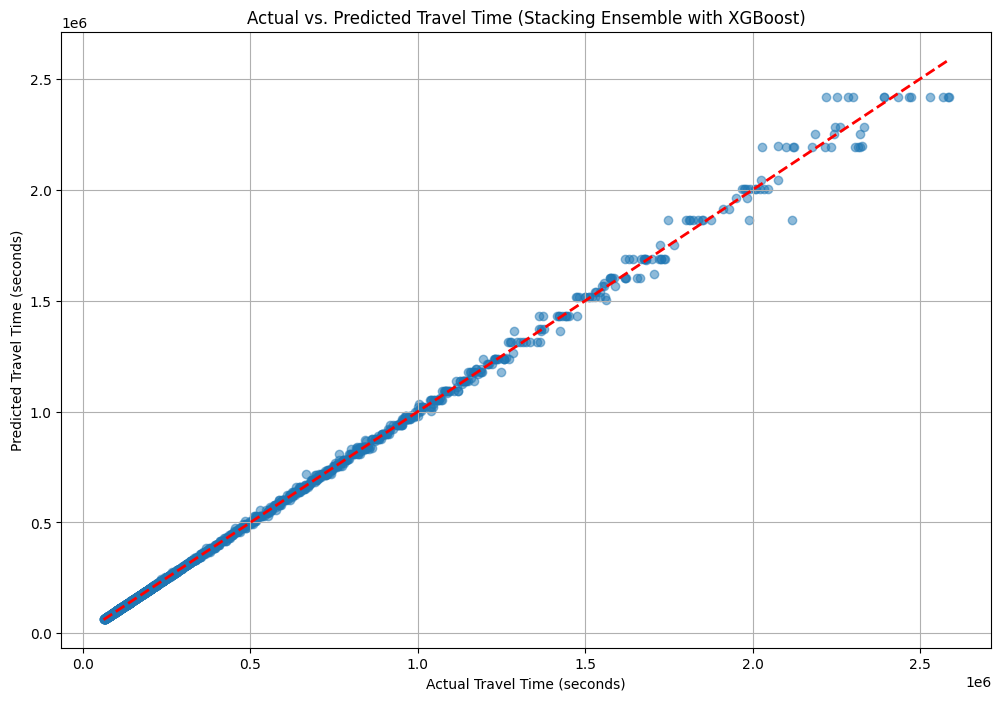

In [10]:
# Plot Actual vs. Predicted
plt.figure(figsize=(12, 8))
plt.scatter(y_test, final_predictions, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.title('Actual vs. Predicted Travel Time (Stacking Ensemble with XGBoost)')
plt.xlabel('Actual Travel Time (seconds)')
plt.ylabel('Predicted Travel Time (seconds)')
plt.grid(True)
plt.show()

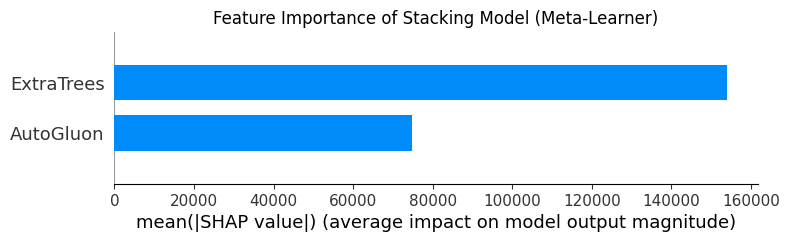

In [15]:
# Function to compute feature importance of the stacking model
def compute_feature_importance(meta_model, meta_features):

    # Create a SHAP explainer for the meta-model
    explainer = shap.TreeExplainer(meta_model)

    # Compute SHAP values for the meta-features
    shap_values = explainer.shap_values(meta_features)

    # Plot the feature importance using SHAP summary plot
    shap.summary_plot(shap_values, meta_features, plot_type="bar", show=False)

    # Add a title to the plot
    plt.title("Feature Importance of Stacking Model (Meta-Learner)")
    plt.show()

# Compute and visualize feature importance for the stacking model
compute_feature_importance(best_xgb_model, meta_features)

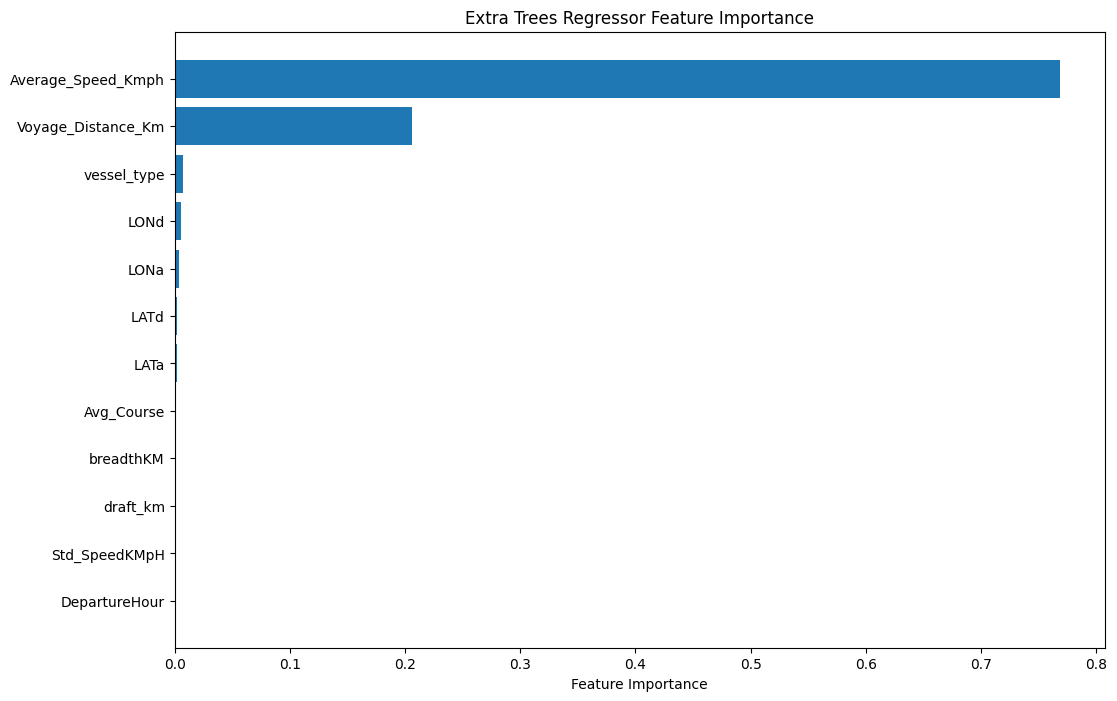

In [11]:
# Feature Importance for Extra Trees Model
et_feature_importance = best_et_model.feature_importances_
feature_names = numeric_features + list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features))

# Aggregate importance for 'vessel_type' (categorical feature)
vessel_type_importance = 0
vessel_type_indices = [i for i, name in enumerate(feature_names) if name.startswith('vessel_type_')]

# Sum the importance of all one-hot encoded columns for 'vessel_type'
for idx in vessel_type_indices:
    vessel_type_importance += et_feature_importance[idx]

# Remove individual one-hot encoded columns from feature_names and feature_importances
feature_names_aggregated = [name for name in feature_names if not name.startswith('vessel_type_')]
feature_importances_aggregated = [importance for i, importance in enumerate(et_feature_importance) if i not in vessel_type_indices]

# Add aggregated 'vessel_type' importance
feature_names_aggregated.append('vessel_type')
feature_importances_aggregated.append(vessel_type_importance)

# Sort feature importance in ascending order
sorted_idx = np.argsort(feature_importances_aggregated)  # Remove [::-1] for ascending order

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(range(len(sorted_idx)), np.array(feature_importances_aggregated)[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), np.array(feature_names_aggregated)[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Extra Trees Regressor Feature Importance')
plt.show()

Computing feature importance via permutation shuffling for 16 features using 1000 rows with 5 shuffle sets...
	163.85s	= Expected runtime (32.77s per shuffle set)
	63.55s	= Actual runtime (Completed 5 of 5 shuffle sets)


Feature Importances from AutoGluon:
                       importance        stddev       p_value  n  \
Average_Speed_Kmph  431275.714817  10730.866387  4.595597e-08  5   
Voyage_Distance_Km  207190.997681   8512.642308  3.411759e-07  5   
DepartureHour          223.476420     76.692358  1.432080e-03  5   
Std_SpeedKMpH          221.627280    231.910934  4.971601e-02  5   
vessel_type_70          63.873097     53.748600  2.827553e-02  5   
vessel_type_90           6.586029     13.009395  1.604456e-01  5   
vessel_type_71           2.798421     12.169371  3.171089e-01  5   
vessel_type_60          -2.060264      2.010723  9.581251e-01  5   
LATd                   -12.819199    302.862255  5.354260e-01  5   
vessel_type_80         -32.930267     11.550306  9.984473e-01  5   
LONd                   -78.216331    257.643498  7.327551e-01  5   
breadthKM              -81.103217     99.318313  9.290551e-01  5   
LONa                  -171.840892    136.587423  9.759201e-01  5   
draft_km    

<Figure size 1000x600 with 0 Axes>

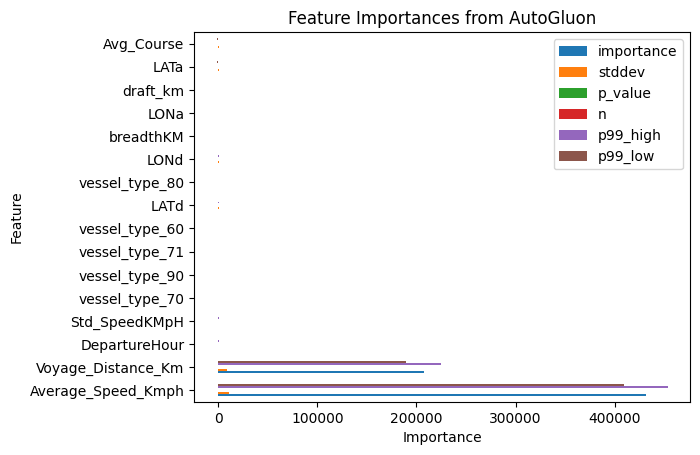

In [12]:
# Feature Importance for AutoGluon Model
test_data_with_labels = pd.concat([pd.DataFrame(X_test, columns=feature_names), y_test.reset_index(drop=True)], axis=1)
test_data_subsample = test_data_with_labels.sample(n=1000, random_state=42)  # Use 1000 samples for faster computation
feature_importances = ag_model.feature_importance(test_data_subsample)

print("Feature Importances from AutoGluon:")
print(feature_importances)

# Visualize Feature Importances
plt.figure(figsize=(10, 6))
feature_importances.plot(kind='barh')
plt.title('Feature Importances from AutoGluon')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()